# 🇧🇷 Projeto: Previsão de Inflação Alta no Brasil
## CRISP-DM — Etapas 3, 4, 5 e 6
**Disciplina:** Projeto Integrado de Ciência de Dados

---
### Objetivo
Classificar se a inflação mensal (IPCA) será **alta (> 0,5%)** ou **baixa (≤ 0,5%)** com base em indicadores macroeconômicos do Brasil entre 1995 e 2025.

---

## BLOCO 1 — Instalação e Importação de Bibliotecas

In [7]:
# Instalação (necessário apenas no Colab)
!pip install scikit-learn pandas matplotlib seaborn --quiet

# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## BLOCO 2 — Carregamento e Exploração dos Dados

In [8]:
df = pd.read_csv('brazil_macro_dataset_synthetic_1995_2025.csv')

print('Shape do dataset:', df.shape)
print()
print('📋 Primeiras linhas:')
df.head()

Shape do dataset: (11323, 11)

📋 Primeiras linhas:


,date,ipca_monthly_pct,selic_rate_pct,usd_brl,gdp_growth_pct,unemployment_pct,fed_funds_rate_pct,us_inflation_pct,exports_usd,imports_usd,dxy_index
0,1995-01-01,0.424507,14.009255,1.649964,3.403253,7.184071,-0.208831,2.373734,1.331743e+10,1.812881e+10,93.500731
1,1995-01-02,0.329280,11.148793,1.059143,1.819950,8.970585,NaN,1.990825,1.399639e+10,2.436003e+10,93.915355
2,1995-01-03,0.447193,12.283418,2.062778,1.833144,9.597145,0.260132,2.110415,1.180461e+10,1.954295e+10,NaN
3,1995-01-04,0.578514,10.333014,3.188404,NaN,7.632133,2.839502,2.299810,1.493101e+10,2.170220e+10,104.123568
4,1995-01-05,0.314957,NaN,3.129469,4.829334,6.594602,1.800879,2.790339,2.570596e+10,2.489706e+10,82.811305


In [9]:
print('Informações das colunas:')
print(df.info())
print()
print('Estatísticas descritivas:')
df.describe()

Informações das colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11323 entries, 0 to 11322
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                11323 non-null  object 
 1   ipca_monthly_pct    11009 non-null  float64
 2   selic_rate_pct      11014 non-null  float64
 3   usd_brl             10960 non-null  float64
 4   gdp_growth_pct      10984 non-null  float64
 5   unemployment_pct    11010 non-null  float64
 6   fed_funds_rate_pct  10967 non-null  float64
 7   us_inflation_pct    11016 non-null  float64
 8   exports_usd         10989 non-null  float64
 9   imports_usd         10953 non-null  float64
 10  dxy_index           10994 non-null  float64
dtypes: float64(10), object(1)
memory usage: 973.2+ KB
None

Estatísticas descritivas:


,ipca_monthly_pct,selic_rate_pct,usd_brl,gdp_growth_pct,unemployment_pct,fed_funds_rate_pct,us_inflation_pct,exports_usd,imports_usd,dxy_index
count,11009.000000,11014.000000,10960.000000,10984.000000,11010.000000,10967.000000,11016.000000,1.098900e+04,1.095300e+04,10994.000000
mean,0.466826,8.371045,3.367809,2.501409,8.988603,2.514920,2.195509,2.004454e+10,1.796494e+10,95.096635
std,0.178874,2.790382,0.779431,1.189721,2.016353,0.998637,0.602844,5.003186e+09,4.981869e+09,6.952777
min,-0.130950,-2.489016,1.047227,-2.654469,2.157241,-1.226141,-0.477781,2.865085e+09,-5.257500e+08,68.521691
25%,0.353924,6.518533,2.848634,1.691034,7.637640,1.831590,1.787832,1.674817e+10,1.461379e+10,90.401465
50%,0.463593,8.332626,3.345450,2.505584,9.001482,2.521778,2.192912,1.998905e+10,1.795844e+10,95.147639
75%,0.574255,10.207339,3.844187,3.310469,10.356174,3.191233,2.603909,2.334461e+10,2.132333e+10,99.820735
max,3.361966,33.548385,14.181436,6.743838,16.490758,5.995113,4.456093,3.914891e+10,3.683090e+10,124.414181


In [10]:
print('Valores nulos por coluna:')
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
pd.DataFrame({'Nulos': nulos, '% do Total': pct_nulos})

Valores nulos por coluna:


,Nulos,% do Total
date,0,0.00
ipca_monthly_pct,314,2.77
selic_rate_pct,309,2.73
usd_brl,363,3.21
gdp_growth_pct,339,2.99
unemployment_pct,313,2.76
fed_funds_rate_pct,356,3.14
us_inflation_pct,307,2.71
exports_usd,334,2.95
imports_usd,370,3.27


## BLOCO 3 — Preparação dos Dados (Data Preparation)

In [11]:
df_modelo = df.drop(columns=['date'])


df_modelo = df_modelo.dropna()
print(f'Registros após limpeza: {len(df_modelo)}')

df_modelo['inflacao_alta'] = (df_modelo['ipca_monthly_pct'] > 0.5).astype(int)

print()
print('Distribuição da variável alvo:')
print(df_modelo['inflacao_alta'].value_counts())
print()
print(f"   Inflação BAIXA (0): {(df_modelo['inflacao_alta']==0).sum()} registros ({(df_modelo['inflacao_alta']==0).mean()*100:.1f}%)")
print(f"   Inflação ALTA  (1): {(df_modelo['inflacao_alta']==1).sum()} registros ({(df_modelo['inflacao_alta']==1).mean()*100:.1f}%)")

Registros após limpeza: 8402

Distribuição da variável alvo:
inflacao_alta
0    4975
1    3427
Name: count, dtype: int64

   Inflação BAIXA (0): 4975 registros (59.2%)
   Inflação ALTA  (1): 3427 registros (40.8%)


In [12]:
X = df_modelo.drop(columns=['ipca_monthly_pct', 'inflacao_alta'])
y = df_modelo['inflacao_alta']

print('Features utilizadas:')
for col in X.columns:
    print(f'   • {col}')
print()
print(f'Shape de X: {X.shape}')
print(f'Shape de y: {y.shape}')

Features utilizadas:
   • selic_rate_pct
   • usd_brl
   • gdp_growth_pct
   • unemployment_pct
   • fed_funds_rate_pct
   • us_inflation_pct
   • exports_usd
   • imports_usd
   • dxy_index

Shape de X: (8402, 9)
Shape de y: (8402,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Dados de TREINO: {X_train.shape[0]} registros')
print(f'Dados de TESTE:  {X_test.shape[0]} registros')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print()
print('Dados normalizados com sucesso!')

Dados de TREINO: 6721 registros
Dados de TESTE:  1681 registros

Dados normalizados com sucesso!


## BLOCO 4 — Modelagem (Treinamento do Modelo)

In [14]:
modelo = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

modelo.fit(X_train_scaled, y_train)

print('Modelo treinado com sucesso!')
print(f'   Algoritmo: Random Forest Classifier')
print(f'   Nº de árvores: 100')
print(f'   Profundidade máxima: 10')

Modelo treinado com sucesso!
   Algoritmo: Random Forest Classifier
   Nº de árvores: 100
   Profundidade máxima: 10


## BLOCO 5 — Validação do Modelo (Etapa 5 do CRISP-DM)

In [15]:
y_pred = modelo.predict(X_test_scaled)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

metricas = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Valor':   [acc, prec, rec, f1],
    'Descrição': [
        'Percentual total de acertos do modelo',
        'Dos que previu como ALTA, quantos realmente eram',
        'Dos que realmente eram ALTA, quantos o modelo acertou',
        'Média harmônica entre Precision e Recall'
    ]
})
metricas['Valor'] = metricas['Valor'].apply(lambda x: f'{x*100:.2f}%')

print('TABELA DE MÉTRICAS DO MODELO')
print('='*60)
print(metricas.to_string(index=False))
print('='*60)

TABELA DE MÉTRICAS DO MODELO
  Métrica  Valor                                             Descrição
 Accuracy 62.17%                 Percentual total de acertos do modelo
Precision 55.68%      Dos que previu como ALTA, quantos realmente eram
   Recall 35.71% Dos que realmente eram ALTA, quantos o modelo acertou
 F1-Score 43.52%              Média harmônica entre Precision e Recall


In [16]:
print(' RELATÓRIO COMPLETO DE CLASSIFICAÇÃO')
print('='*50)
print(classification_report(y_test, y_pred,
      target_names=['Inflação Baixa (0)', 'Inflação Alta (1)']))

 RELATÓRIO COMPLETO DE CLASSIFICAÇÃO
                    precision    recall  f1-score   support

Inflação Baixa (0)       0.64      0.80      0.72       995
 Inflação Alta (1)       0.56      0.36      0.44       686

          accuracy                           0.62      1681
         macro avg       0.60      0.58      0.58      1681
      weighted avg       0.61      0.62      0.60      1681



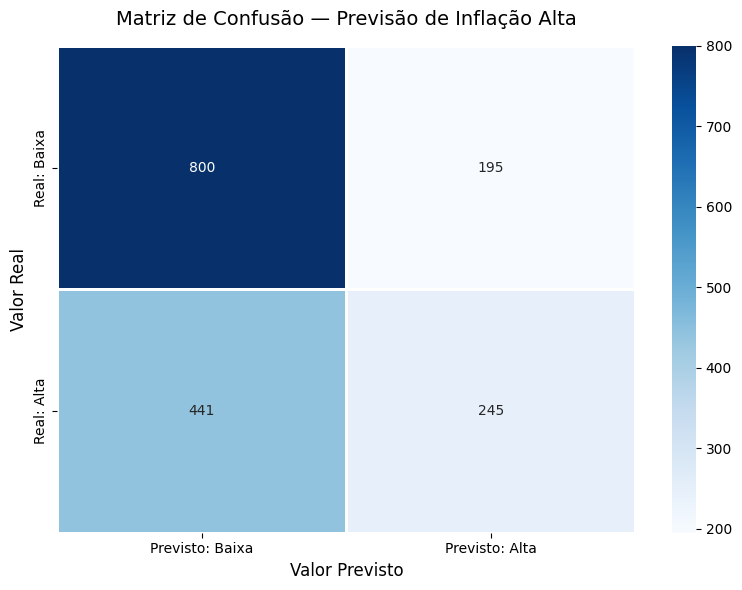

Gráfico salvo: grafico_matriz_confusao.png


In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto: Baixa', 'Previsto: Alta'],
            yticklabels=['Real: Baixa', 'Real: Alta'],
            linewidths=1, linecolor='white')
plt.title('Matriz de Confusão — Previsão de Inflação Alta', fontsize=14, pad=15)
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Valor Previsto', fontsize=12)
plt.tight_layout()
plt.savefig('grafico_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: grafico_matriz_confusao.png')

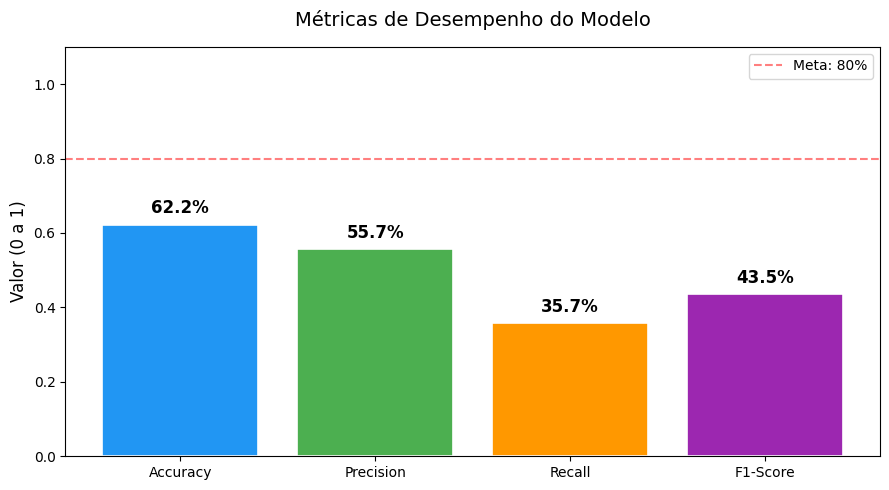

Gráfico salvo: grafico_metricas.png


In [18]:
nomes   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
valores = [acc, prec, rec, f1]
cores   = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

plt.figure(figsize=(9, 5))
bars = plt.bar(nomes, valores, color=cores, edgecolor='white', linewidth=1.2)
plt.ylim(0, 1.1)
plt.title('Métricas de Desempenho do Modelo', fontsize=14, pad=15)
plt.ylabel('Valor (0 a 1)', fontsize=12)

for bar, val in zip(bars, valores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val*100:.1f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Meta: 80%')
plt.legend()
plt.tight_layout()
plt.savefig('grafico_metricas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: grafico_metricas.png')

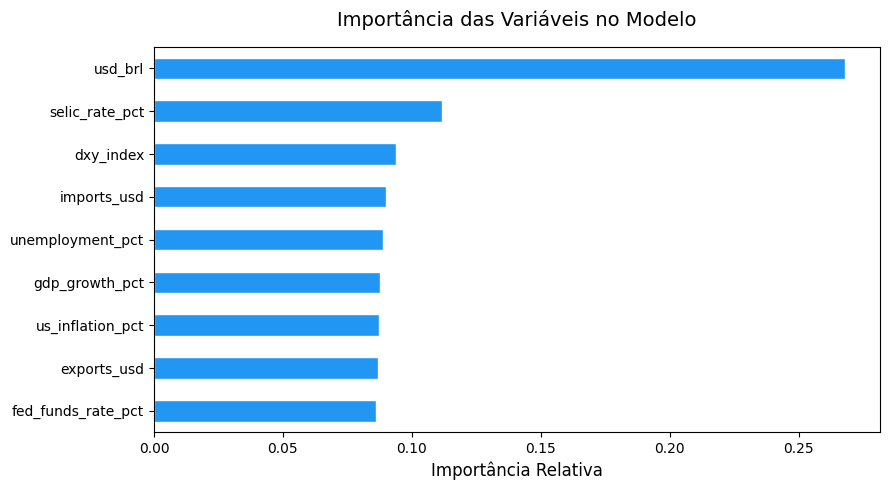

Gráfico salvo: grafico_importancia_features.png


In [19]:
importancias = pd.Series(modelo.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importancias.plot(kind='barh', color='#2196F3', edgecolor='white')
plt.title('Importância das Variáveis no Modelo', fontsize=14, pad=15)
plt.xlabel('Importância Relativa', fontsize=12)
plt.tight_layout()
plt.savefig('grafico_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: grafico_importancia_features.png')

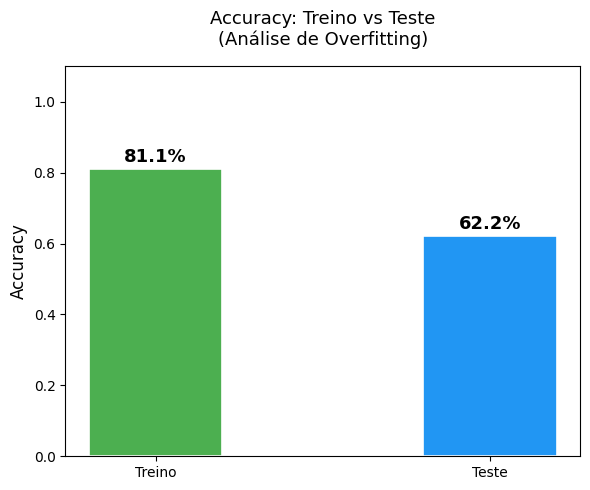

Accuracy Treino: 81.10%
Accuracy Teste:  62.17%
Diferença:       18.94%
Diferença alta — possível overfitting!


In [20]:
y_pred_train = modelo.predict(X_train_scaled)

acc_treino = accuracy_score(y_train, y_pred_train)
acc_teste  = accuracy_score(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.bar(['Treino', 'Teste'], [acc_treino, acc_teste],
        color=['#4CAF50', '#2196F3'], edgecolor='white', linewidth=1.2, width=0.4)
plt.ylim(0, 1.1)
plt.title('Accuracy: Treino vs Teste\n(Análise de Overfitting)', fontsize=13, pad=15)
plt.ylabel('Accuracy', fontsize=12)

for i, val in enumerate([acc_treino, acc_teste]):
    plt.text(i, val + 0.02, f'{val*100:.1f}%', ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('grafico_overfitting.png', dpi=150, bbox_inches='tight')
plt.show()

diff = abs(acc_treino - acc_teste)
print(f'Accuracy Treino: {acc_treino*100:.2f}%')
print(f'Accuracy Teste:  {acc_teste*100:.2f}%')
print(f'Diferença:       {diff*100:.2f}%')
if diff < 0.05:
    print('Diferença pequena — modelo sem overfitting significativo!')
else:
    print('Diferença alta — possível overfitting!')

## BLOCO 6 — Exportação dos Resultados (para Power BI)

In [21]:
resultados = pd.DataFrame({
    'Real':    y_test.values,
    'Previsto': y_pred,
    'Acerto':  (y_test.values == y_pred).astype(int)
})
resultados['Real_Label']    = resultados['Real'].map({0:'Baixa', 1:'Alta'})
resultados['Previsto_Label']= resultados['Previsto'].map({0:'Baixa', 1:'Alta'})
resultados['Acerto_Label']  = resultados['Acerto'].map({0:'Erro', 1:'Acerto'})

resultados.to_csv('resultados_modelo.csv', index=False)
print('Arquivo salvo: resultados_modelo.csv')

# Exportar tabela de métricas
metricas_export = pd.DataFrame({
    'Metrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Valor':   [round(acc,4), round(prec,4), round(rec,4), round(f1,4)],
    'Percentual': [f'{v*100:.2f}%' for v in [acc, prec, rec, f1]]
})
metricas_export.to_csv('metricas_modelo.csv', index=False)
print('Arquivo salvo: metricas_modelo.csv')

# Exportar importância das features
importancias_export = pd.DataFrame({
    'Feature': X.columns,
    'Importancia': modelo.feature_importances_
}).sort_values('Importancia', ascending=False)
importancias_export.to_csv('importancia_features.csv', index=False)
print('Arquivo salvo: importancia_features.csv')

print()
print('Todos os arquivos exportados! Baixe-os para usar no Power BI.')

Arquivo salvo: resultados_modelo.csv
Arquivo salvo: metricas_modelo.csv
Arquivo salvo: importancia_features.csv

Todos os arquivos exportados! Baixe-os para usar no Power BI.


---
## BLOCO 7 — Resumo Final dos Resultados

Execute esta célula para ver um resumo completo do projeto.

In [22]:
print('=' * 60)
print('           RESUMO FINAL DO PROJETO')
print('=' * 60)
print(f'  Dataset:       Indicadores Macroeconômicos do Brasil')
print(f'  Período:       1995 – 2025')
print(f'  Registros:     {len(df_modelo):,}')
print(f'  Algoritmo:     Random Forest Classifier')
print()
print(f'  MÉTRICAS DE DESEMPENHO:')
print(f'  • Accuracy:  {acc*100:.2f}%')
print(f'  • Precision: {prec*100:.2f}%')
print(f'  • Recall:    {rec*100:.2f}%')
print(f'  • F1-Score:  {f1*100:.2f}%')
print()
print(f'  ARQUIVOS GERADOS:')
print(f'  • grafico_matriz_confusao.png')
print(f'  • grafico_metricas.png')
print(f'  • grafico_importancia_features.png')
print(f'  • grafico_overfitting.png')
print(f'  • resultados_modelo.csv')
print(f'  • metricas_modelo.csv')
print(f'  • importancia_features.csv')
print('=' * 60)

           RESUMO FINAL DO PROJETO
  Dataset:       Indicadores Macroeconômicos do Brasil
  Período:       1995 – 2025
  Registros:     8,402
  Algoritmo:     Random Forest Classifier

  MÉTRICAS DE DESEMPENHO:
  • Accuracy:  62.17%
  • Precision: 55.68%
  • Recall:    35.71%
  • F1-Score:  43.52%

  ARQUIVOS GERADOS:
  • grafico_matriz_confusao.png
  • grafico_metricas.png
  • grafico_importancia_features.png
  • grafico_overfitting.png
  • resultados_modelo.csv
  • metricas_modelo.csv
  • importancia_features.csv
